In [8]:
from src.data_loader import load_categories, save_raw, load_raw, raw_data_exists
from src.preprocessing import preprocess, save_processed, load_processed, processed_data_exists
from src.sentiment import load_model, predict, filter_low_confidence, save_with_sentiment, load_with_sentiment, sentiment_data_exists
from src.mismatch import classify, summary, summary_by_rating, sample_mismatches, save_classified, load_classified, classified_data_exists
from src.analysis import plot_mismatch_by_category, plot_mismatch_by_rating, plot_mismatch_direction, save_summary_tables, qualitative_table

In [ ]:
FORCE_RELOAD = False

In [10]:
if (not raw_data_exists() or FORCE_RELOAD):
	df_raw = load_categories(["Electronics", "Clothing", "Books"], n_samples_per_category=1000)
	save_raw(df_raw)
else:
	print("Raw data already exists. Skipping streaming step.")
	df_raw = load_raw()

[Electronics] Connecting to HuggingFace...
[Electronics] Sampling 1000 reviews...
[Electronics] Done — 1,000 reviews loaded.
[Clothing] Connecting to HuggingFace...
[Clothing] Sampling 1000 reviews...
[Clothing] Done — 1,000 reviews loaded.
[Books] Connecting to HuggingFace...
[Books] Sampling 1000 reviews...
[Books] Done — 1,000 reviews loaded.

Total reviews loaded: 3,000
category
Electronics    1000
Clothing       1000
Books          1000

Raw data saved to data/raw/reviews_raw.parquet  (3,000 rows)


In [11]:
if (not processed_data_exists() or FORCE_RELOAD):
	df_clean = preprocess(df_raw)
	save_processed(df_clean)
else:
	print("Processed data already exists. Skipping preprocessing step.")
	df_clean = load_processed()

Starting preprocessing pipeline...
  Input: 3,000 reviews

  [drop_missing] 3,000 → 3,000  (removed 0 = 0.0%)
  [drop_duplicates] 3,000 → 1,817  (removed 1,183 = 39.4%)
  [drop_short (< 10 words)] 1,817 → 1,382  (removed 435 = 23.9%)


Detecting language: 100%|██████████| 1382/1382 [00:02<00:00, 466.15it/s]

  [filter_english] 1,382 → 1,377  (removed 5 = 0.4%)

Preprocessing complete.
  Output: 1,377 reviews

Rating sentiment distribution:
rating_sentiment
positive    1102
negative     168
neutral      107

By category:
category     rating_sentiment
Books        positive            352
             neutral              29
             negative             26
Clothing     positive            317
             negative             55
             neutral              39
Electronics  positive            433
             negative             87
             neutral              39
Processed data saved to data/processed/reviews_processed.parquet  (1,377 rows)


In [12]:
if (not sentiment_data_exists() or FORCE_RELOAD):
	classifier = load_model()
	df_sentiment = predict(df_clean, classifier)
	df_sentiment = filter_low_confidence(df_sentiment, threshold=0.60)
	save_with_sentiment(df_sentiment)
else:
	print("Sentiment data already exists. Skipping sentiment analysis step.")
	df_sentiment = load_with_sentiment()

Loading sentiment model on CPU...
  Model : cardiffnlp/twitter-roberta-base-sentiment-latest
  Batch size: 32


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.

Running sentiment analysis on 1,377 reviews...


Sentiment inference:   0%|          | 0/44 [00:00<?, ?batch/s]


Prediction complete.
Text sentiment distribution:
text_sentiment
positive    1012
negative     210
neutral      155

Mean confidence score: 0.837
[filter_low_confidence (threshold=0.6)] 1,377 → 1,170  (removed 207 = 15.0%)
Saved to data/processed/reviews_with_sentiment.parquet  (1,170 rows)


In [14]:
if (not classified_data_exists() or FORCE_RELOAD):
	df_classified = classify(df_sentiment)
	save_classified(df_classified)
else:
	print("Classified data already exists. Skipping classification step.")
	df_classified = load_classified()

Mismatch classification complete.

Overall mismatch rate: 11.0%

Mismatch type counts:
mismatch_type
match              1041
soft_mismatch        98
strong_mismatch      31
Saved classified data to data/processed/reviews_with_mismatch.parquet  (1,170 rows)


Saved figure → results/figures/mismatch_by_category.png / .pdf
Saved figure → results/figures/mismatch_by_rating.png / .pdf


/Users/vicvsl/dev/tudelft/WebSciEng/src/analysis.py:199: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
/Users/vicvsl/dev/tudelft/WebSciEng/src/analysis.py:79: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out, bbox_inches="tight")


Saved figure → results/figures/mismatch_direction_by_category.png / .pdf
Saved summary_by_category  → results/tables
Saved summary_by_rating    → results/tables


,category,Stars,Rating sentiment,Text sentiment,Confidence,Direction,Review excerpt
0,Clothing,4.0,positive,negative,0.8229,text_more_negative,Tag in back is super scratchy and the gown rip...
1,Clothing,2.0,negative,positive,0.6775,text_more_positive,"I am a longtime Brooks wearer, so when I was o..."
2,Books,5.0,positive,negative,0.9094,text_more_negative,"Great stories, but hated when he was making he..."
3,Electronics,2.0,negative,positive,0.8470,text_more_positive,Our charity involves taking pictures and trans...
4,Electronics,5.0,positive,negative,0.6658,text_more_negative,I had a micro sd card in my phone for a couple...
5,Clothing,5.0,positive,negative,0.8922,text_more_negative,Doesn’t wash well and fabric not soft even aft...
6,Electronics,5.0,positive,negative,0.8268,text_more_negative,My cat has chewed through so many cords - I ha...
7,Electronics,5.0,positive,negative,0.7766,text_more_negative,Too heavy to adhere. I had to use duct tape to...
8,Electronics,1.0,negative,positive,0.9481,text_more_positive,"Absolutely loved the color, feel, and clasp me..."
9,Electronics,1.0,negative,positive,0.8334,text_more_positive,This remote was slightly higher priced than th...


/Users/vicvsl/dev/tudelft/WebSciEng/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  func(*args, **kwargs)


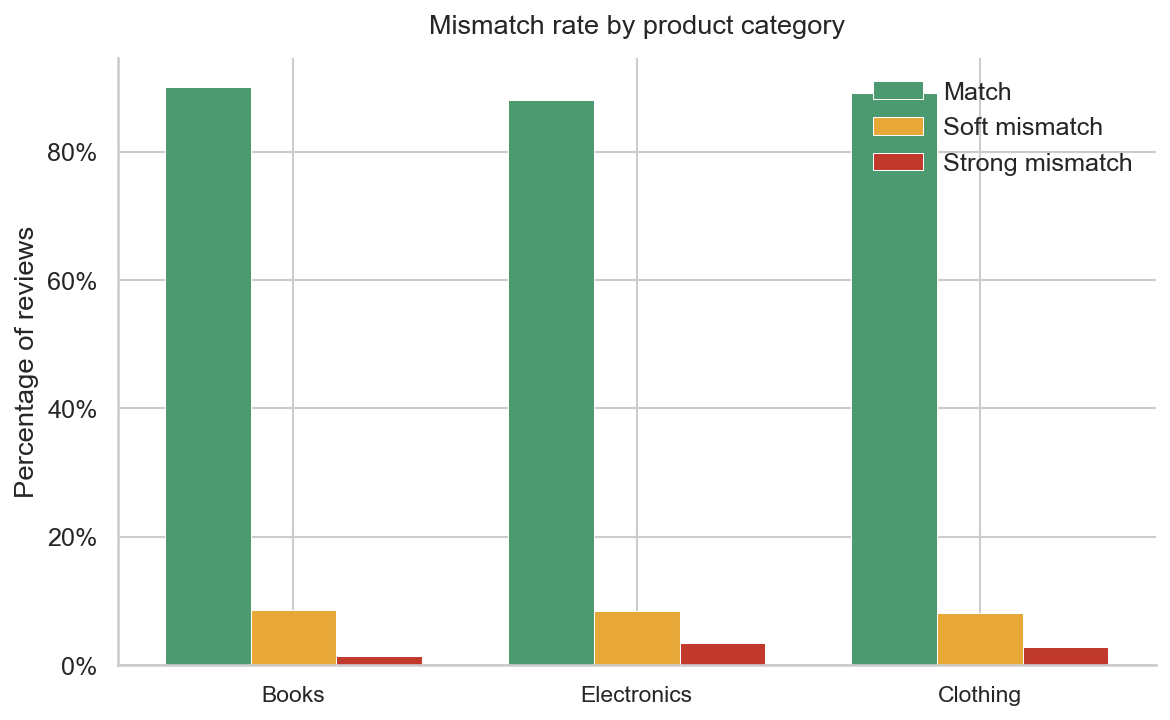

/Users/vicvsl/dev/tudelft/WebSciEng/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


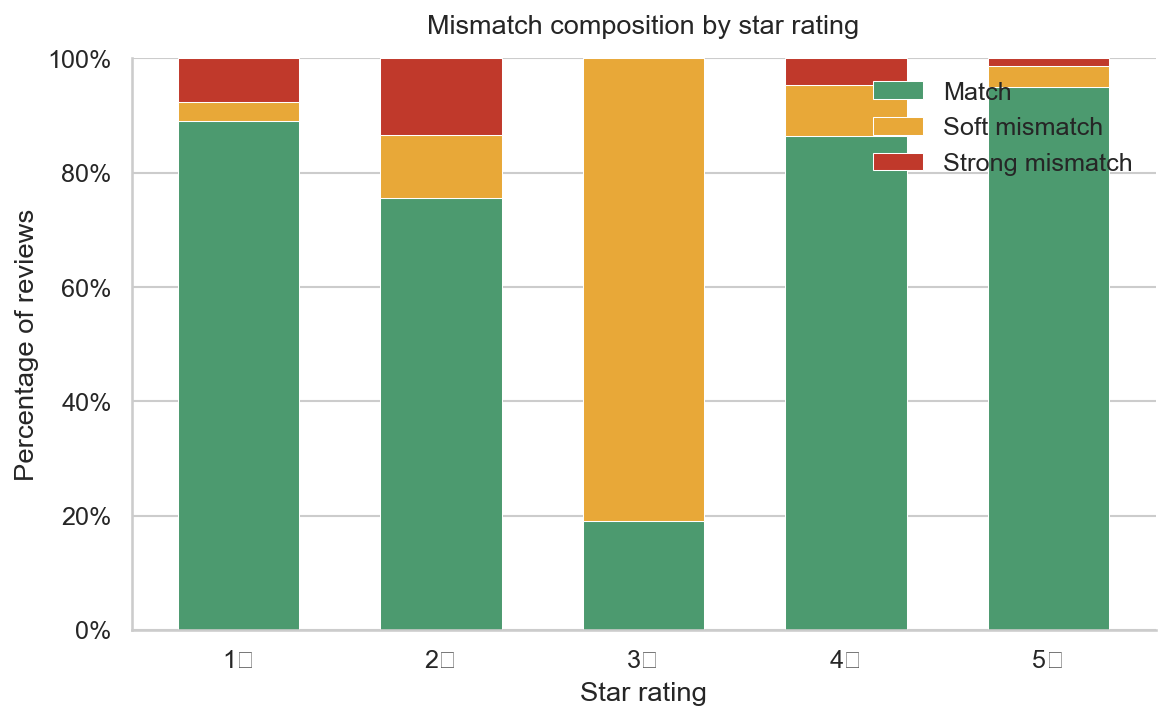

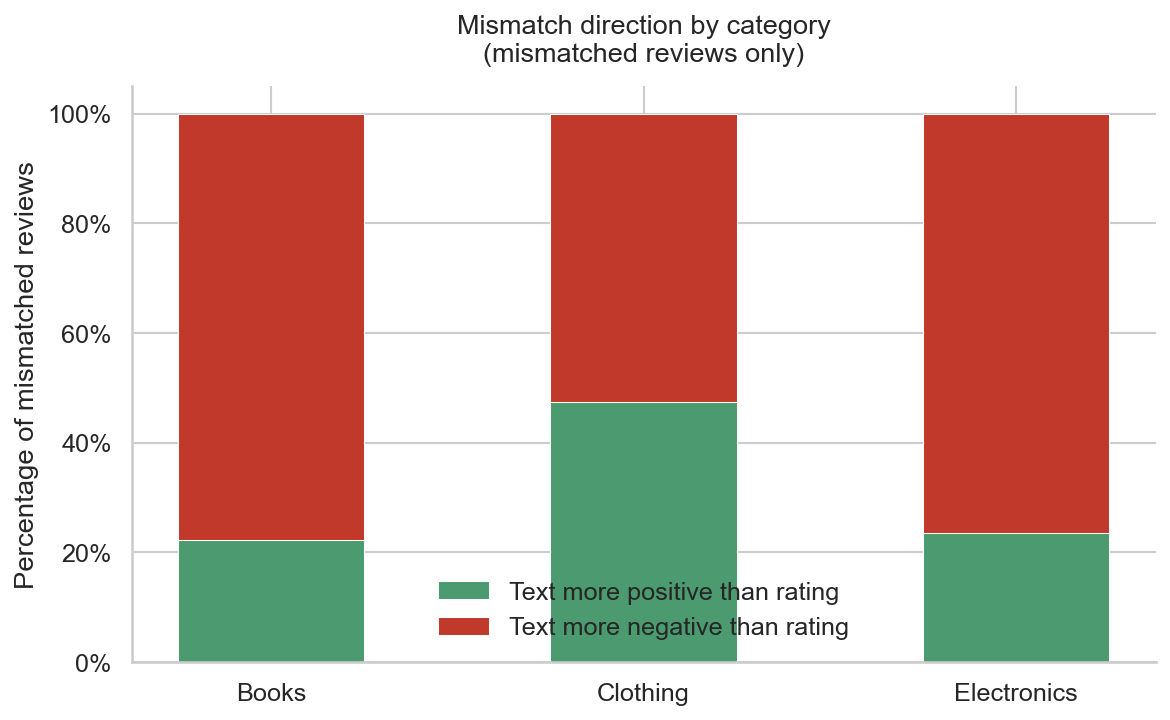

In [15]:
df = df_classified.copy()
plot_mismatch_by_category(df)
plot_mismatch_by_rating(df)
plot_mismatch_direction(df)
save_summary_tables(df)
qualitative_table(df)